In [1]:
# Dont delete this - this is necessary to run it on colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  %cd /content/drive/MyDrive/Python Code/Paper_condensed/scripts/
from pathlib import Path

In [2]:
savefig=True
figpath=Path("../results/")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import ipywidgets as widgets
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
try:
  import scikit_posthocs as sp
except:
  %pip install scikit_posthocs
  import scikit_posthocs as sp
import colorsys
from matplotlib.colors import to_rgb, to_hex
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import colorsys
import matplotlib as mpl

# helper to boost saturation / darken
def adjust_saturation(hex_color, sat_factor=1.4, light_factor=1.0):
    """
    Adjust saturation and lightness for a hex color.
      - sat_factor > 1 boosts saturation
      - light_factor < 1 darkens
    """
    r, g, b = mpl.colors.to_rgb(hex_color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    s = max(0, min(1, s * sat_factor))
    l = max(0, min(1, l * light_factor))
    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return mpl.colors.to_hex((r2, g2, b2))

In [5]:
from load_rivers import *

C:\Users\foxni\Documents\NWP_Land_Sea_Fluxes\scripts\load_rivers.py:109: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('b.d.', 0.0, inplace=True)


In [6]:
# Set constituents, rivers, colors, and order

chemicals = ["dSi", "TN", "TP", "Fe", "TSS"]
rivers = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
rivercolors = ["#f3d658", "#e1c9a8", "#e8a3cb", "#a6b6d2", "#f9a68a"]
streamflow_colors = ["gray"] * 5

# from data_post_condensed
def colorset1():
  global rivercolors, vivid_colors, point_colors, streamflow_colors
  rivercolors = ["#f3d658", "#e1c9a8", "#e8a3cb", "#a6b6d2", "#f9a68a"]
  vivid_colors = ['#ffde4c', '#eccb9d', '#f695cd', '#9db4db', '#ffa384'] #adjust_saturation(c, sat_factor=1.4, light_factor=1.0)
  point_colors = ['#e8bd00', '#ff9d14', '#ff169c', '#286cdf', '#ff4c10'] #adjust_saturation(c, sat_factor=1.6, light_factor=0.7)
  streamflow_colors = ["gray"] * 5
def colorset2():
  global rivercolors, vivid_colors, point_colors, streamflow_colors
  rivercolors = ["#AB200C", "#DB7509", "#E8BC0C", "#0DBA9C", "#2966A6"]
  vivid_colors = [adjust_saturation(c, sat_factor=1.4, light_factor=1.0) for c in rivercolors]
  point_colors = [adjust_saturation(c, sat_factor=1.6, light_factor=0.7) for c in rivercolors]
  streamflow_colors = [adjust_saturation(c, sat_factor=0.8, light_factor=0.7) for c in rivercolors]
colorset2()

In [7]:
names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
drop_cols = ['Team', 'Site', 'Time', 'replicate', 'Temp', 'Baro']
chemdfs = ([
    raw_chem_dfs[name]
    .drop(columns=drop_cols, index=pd.NaT, errors="ignore")
    .sort_index()
    .truncate(before="2022-04-01", after="2023-03-31")
    .reset_index()
    for name in names
    ])
(Puelo_Chem, Yelcho_Chem, Palena_Chem, Cisnes_Chem, Aysen_Chem) = chemdfs

In [8]:
#### Alternative to above for dataframe setup, avoiding loss of data on date merge

def chem_summary_long(chemdfs: list[pd.DataFrame], names: list[str], col: str) -> pd.DataFrame:
    # Build a long-form DataFrame that stacks the measurements regardless of date
    pieces = []
    for name, df in zip(names, chemdfs):
        s = df[col].dropna().reset_index(drop=True)  # ignore the dates
        temp = pd.DataFrame({'River': name, 'Concentration': s})
        pieces.append(temp)
    return pd.concat(pieces, ignore_index=True)

In [9]:
def plot_tabbed(plotter):
    def wrapper(titles, instance_args):
        assert len(titles)==len(instance_args)
        # turn inline off
        %matplotlib
        tab = widgets.Tab()
        for title, args in zip(titles, instance_args):
            out = widgets.Output()
            tab.children = tab.children + (out,)
            #print(args)
            with out:
                fig, ax = plt.subplots()
                plotter(*args, ax=ax)
                #out.set_title(title)
                display(fig)
        #tab.titles = titles
        [tab.set_title(i, title) for i, title in enumerate(titles)] # Ty https://stackoverflow.com/a/61130993
        display(tab)
    return wrapper

In [10]:
#names, chemdfs = zip(*chem_dfs.items())
chemicals = ["Total Nitrogen", "Total Phosphorus", "Dissolved Silica", "Iron", "Dissolved Organic Carbon", "Total Suspsended Solids"]
chemicals_short = ["TN", "TP", "dSi", "DSi", "Fe", "TSS", "DOC"]
for df in chemdfs:
    df.rename(dict(zip(chemicals, chemicals_short)), axis=1, inplace=True)

In [11]:
# Select desired constituents for analysis

chemicals = ['TN', 'TP', 'dSi', 'Fe', 'TSS','DOC']

In [12]:
###### Dataframe setup

# Use the long-format function instead of the old chem_summary function.
summary_long = {c: chem_summary_long(chemdfs, rivers, c) for c in chemicals}

In [13]:
#### Omit Outliers using two-sided z score ### Optional Step for validation of messy data only if needed

z_score = 10 #if set very high, this does nothing.

# Define a function that removes outliers on a per‑river basis.
def remove_outliers_long(df, z_thresh=z_score):
    """
    For a long-format DataFrame with columns "River" and "Concentration",
    remove rows for which the absolute z-score (computed within each river group)
    is greater than or equal to z_thresh.
    """
    def filter_group(group):
        # If there are fewer than 2 values, z-score is not meaningful.
        if len(group) < 2:
            return group
        z_scores = stats.zscore(group['Concentration'], nan_policy='omit')
        return group[np.abs(z_scores) < z_thresh]

    # Apply the filtering by grouping on 'River'
    return df.groupby("River", group_keys=False).apply(filter_group)

# (Optional) Compute and print the number of outliers that would be removed for each river‐constituent pair.
outlier_counts_long = {}
for chem, df in summary_long.items():
    # Group by river and count values with absolute z-score >= z_thresh
    counts = df.groupby("River")["Concentration"].apply(
        lambda x: (np.abs(stats.zscore(x, nan_policy='omit')) >= z_score).sum()
    )
    outlier_counts_long[chem] = counts

# Create a table of outlier counts
outliers_table_long = pd.DataFrame(outlier_counts_long).T
outliers_table_long.index.name = "Constituent"

print("Number of values omitted (outliers) per river-constituent pair:")
display(outliers_table_long)

# Now remove the outliers from each constituent’s long-format DataFrame.
summary_long_filtered = {chem: remove_outliers_long(df, z_thresh=z_score)
                           for chem, df in summary_long.items()}

Number of values omitted (outliers) per river-constituent pair:


River,Aysen,Cisnes,Palena,Puelo,Yelcho
Constituent,,,,,
TN,0,0,0,0,0
TP,0,0,0,0,0
dSi,0,0,0,0,0
Fe,0,0,0,0,0
TSS,0,0,0,0,0
DOC,0,0,0,0,0


C:\Users\foxni\AppData\Local\Temp\ipykernel_33492\4098264855.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("River", group_keys=False).apply(filter_group)
C:\Users\foxni\AppData\Local\Temp\ipykernel_33492\4098264855.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("River", group_keys=False).apply(filter_group)
C:\Users\foxni\AppData\Local\Temp\ipykernel_33492\4098264855.p

In [14]:
# Define which constituents should be converted to mg/L.

convert_to_mg = ["DOC", "dSi", "TSS"]  # Select constituents not already in mg/L

label_only_mg = ["DOC", "dSi", "TSS"] # These are already reported in mg/L in raw dataset, but defauly units on lable need to be changed

In [15]:
savefig = True

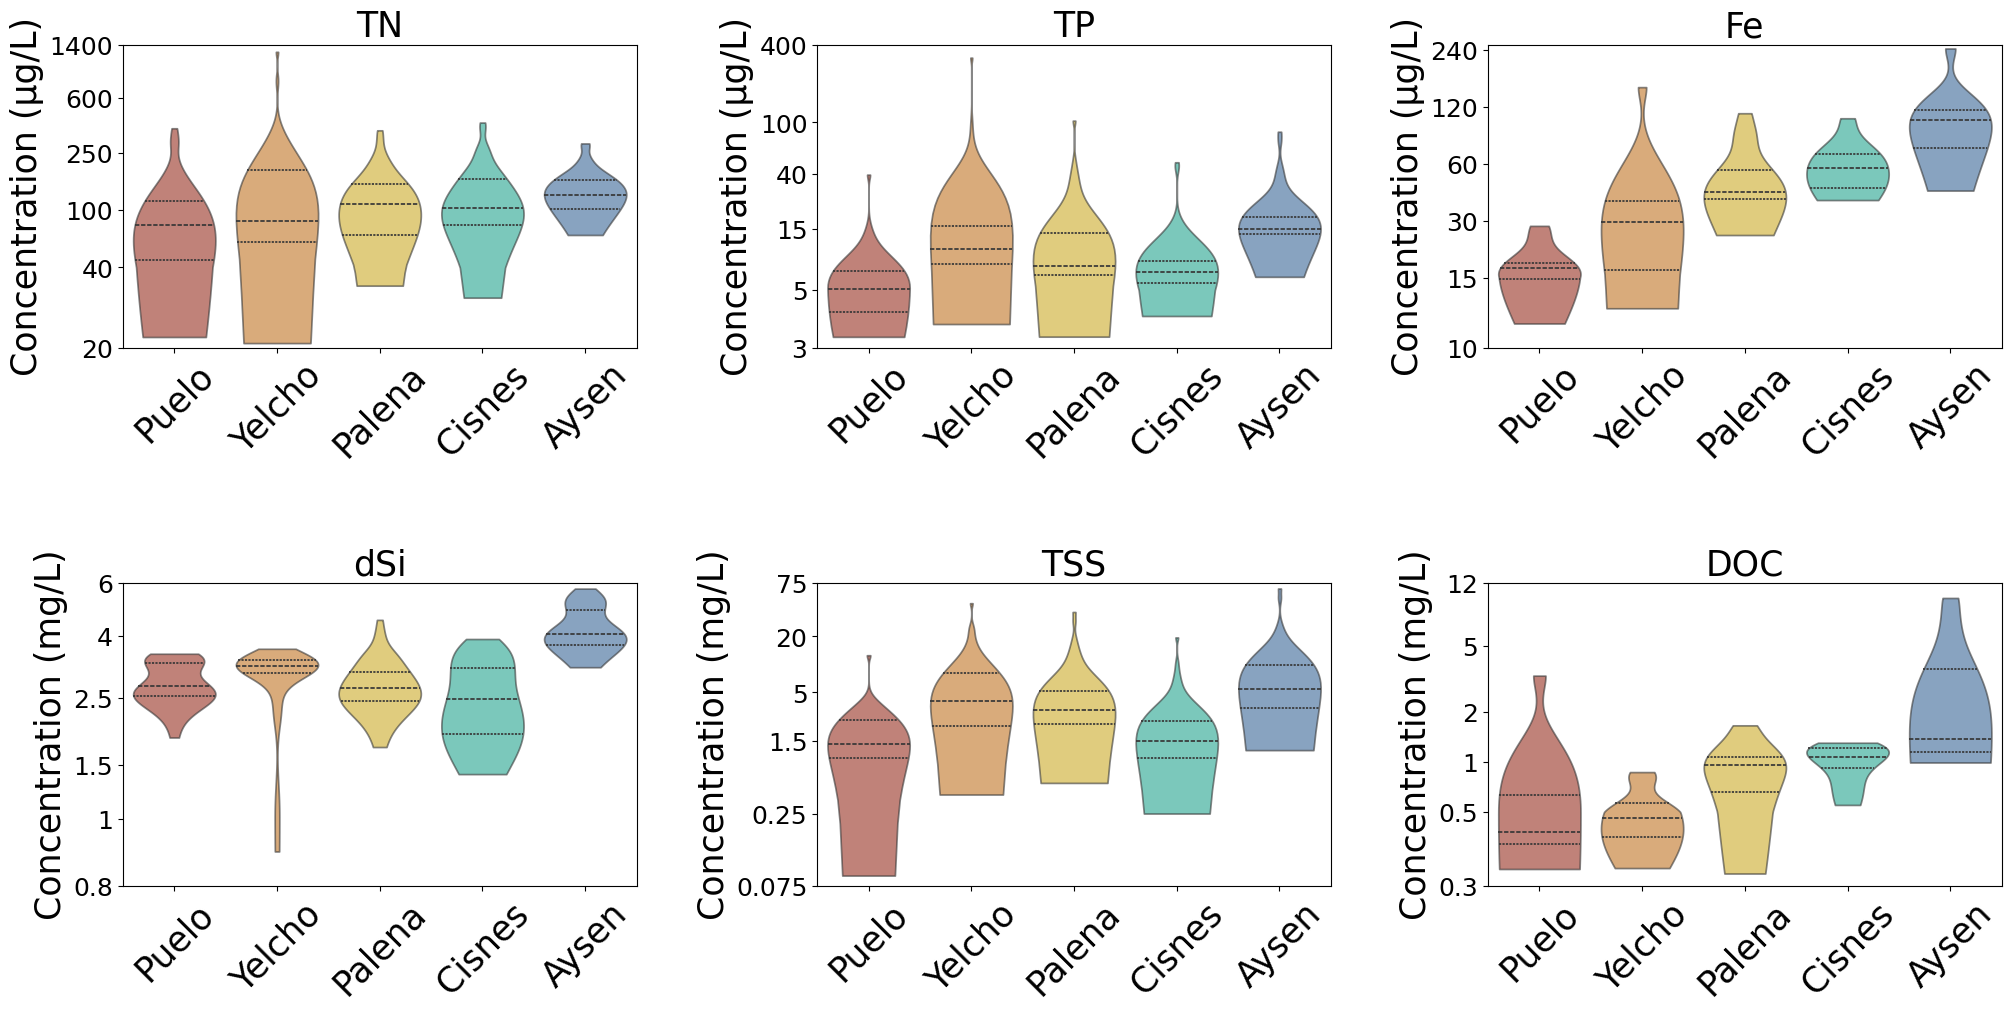

In [21]:
##### LOG‐SCALE (SYMLOG) VERSION WITH MANUAL PER‐PLOT Y‐TICKS, NO LETTER ANNOTATIONS,
##### AND Y-AXIS MIN BOUND SET TO LOWEST TICK
import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import NullLocator
from collections import OrderedDict

# --- User‐provided objects (must be defined before running this) ---
# summary_long_filtered: Ordered dict {constituent_name: DataFrame}
# figpath: path where to save figures (string)
# convert_to_mg: list of constituent names to convert from µg/L → mg/L
# label_only_mg: list of constituent names reported in mg/L but need that label

# -------------------------------
# Force constituents into the desired order
constituent_order = ['TN', 'TP', 'Fe', 'dSi', 'TSS', 'DOC']
summary_long_filtered = OrderedDict(
    (k, summary_long_filtered[k]) for k in constituent_order
)


def cld_from_pvals(pvals, alpha=0.05):
    groups = list(pvals.index)
    letter_assignment = {g: set() for g in groups}
    letters = []
    for g in groups:
        assigned = False
        for letter in letters:
            same = [h for h in groups if letter in letter_assignment[h]]
            if all(pvals.loc[g, h] >= alpha for h in same):
                letter_assignment[g].add(letter)
                assigned = True
                break
        if not assigned:
            new_letter = chr(65 + len(letters))
            letters.append(new_letter)
            letter_assignment[g].add(new_letter)
    return {g: "".join(sorted(letter_assignment[g])) for g in groups}

# -------------------------------
# Manual tick lists for each subplot (in the same order as summary_long_filtered.keys())
tick_lists = [
    [20, 40, 100, 250, 600, 1400],   # TN
    [3, 5, 15, 40, 100, 400],        # TP
    [10, 15, 30, 60, 120, 240],      # Fe
    [0.8, 1, 1.5, 2.5, 4, 6],        # dSi
    [0.075, 0.25, 1.5, 5, 20, 75],   # TSS
    [0.3, 0.5, 1, 2, 5, 12],         # DOC
]

# Manual cld letter positions for each subplot
cld_y_positions = [
    [0.2, 0.2, 0.3, 0.3, 0.4],
    [0.4, 0.1, 0.15, 0.15, 0.3],
    [0.1, 0.15, 0.5, 0.5, 0.6],
    [0.15, 0.2, 0.5, 0.4, 0.8],
    [0.6, 0.95, 0.95, 0.9, 0.9],
    [0.65, 0.55, 0.1, 0.2, 0.5]
]


# -------------------------------
# Plotting
# -------------------------------
fig, axes = plt.subplots(
    nrows=2, ncols=3, figsize=(20, 10),
    gridspec_kw={'hspace': 0.17, 'wspace': 0.09},
    constrained_layout=True
)
axes = axes.flatten()

for (chem, df), ax, ticks, cld_y in zip(summary_long_filtered.items(), axes, tick_lists, cld_y_positions):
    # drop zeros/negatives (we'll still show zero via symlog)
    df = df[df["Concentration"] > 0].copy()

    # unit conversion & y‐axis label
    if chem in convert_to_mg:
        df["Concentration"] /= 1000
        ylabel = "Concentration (mg/L)"
    elif chem in label_only_mg:
        ylabel = "Concentration (mg/L)"
    else:
        ylabel = "Concentration (µg/L)"

    # violin plot
    sns.violinplot(
        data=df,
        x='River', y='Concentration',
        hue='River',
        order=rivers,
        palette=dict(zip(rivers, rivercolors)),
        dodge=False,
        ax=ax,
        inner="quartile",
        cut=0,
        legend=False,
        alpha=0.6
    )

    # symlog scale so we can include zero
    lin_thresh = ticks[1] if len(ticks) > 1 else 1.0
    ax.set_yscale('symlog', linthresh=lin_thresh)

    # manual ticks and labels
    ax.set_yticks(ticks)
    ax.set_yticklabels([str(v) for v in ticks])
    ax.yaxis.set_minor_locator(NullLocator())

    # set y‐axis bottom to lowest tick
    ax.set_ylim(bottom=ticks[0])

    # compute CLDs (annotations commented out)
    dunn = sp.posthoc_dunn(df, val_col="Concentration", group_col="River", p_adjust="bonferroni")
    cld = cld_from_pvals(dunn, alpha=0.05)
    # annotate the plots
    cld_y = np.array(cld_y)*(ax.get_ylim()[1] - ax.get_ylim()[0])
    # for letter, x, y in zip(cld.values(), [0.0, 1.0, 2.0, 3.0, 4.0], cld_y):
    #     ax.text(x, y, letter, ha='center', va='center', color='black', fontsize=20)


    ax.set_title(chem, fontsize=25)
    ax.set_ylabel(ylabel, fontsize=25)
    ax.set_xlabel("")
    ax.tick_params(axis='x', labelsize=25, rotation=45)
    ax.tick_params(axis='y', labelsize=18)

plt.suptitle("", fontsize=22, y=1.02)
if savefig:
  plt.savefig(figpath / "chem_violin_plots_log_manual_ticks_ylim.png", dpi=800, bbox_inches="tight")
plt.show()

In [ ]:
# # ##### FOUND THE VIOLIN PLOTS (Figure 3)
# # ##### UNDER LINK https://drive.google.com/file/d/1IIO7VXeegH9jaRIF_XNGsnnkulHLVJCm/view?usp=drive_link
# # ##### FILE PATH Paper/figures/chemistry/conc/violinplots/chem_violin_plots_log_manual_ticks_ylim.png
# # ##### GENERATED BY last cell in Paper/scripts/chemistry/boxplots.ipynb
# # ##### aka https://drive.google.com/file/d/1MTvQsFskn0LlREoS2UXm435sqlo3JVEo/view?usp=drive_link

# # ####### LOG‐SCALE (SYMLOG) VERSION WITH MANUAL PER‐PLOT Y‐TICKS, NO LETTER ANNOTATIONS,
# ##### AND Y-AXIS MIN BOUND SET TO LOWEST TICK
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import colorsys
# from matplotlib.colors import to_rgb, to_hex
# import scikit_posthocs as sp        # for posthoc_dunn
# from matplotlib.ticker import NullLocator
# from collections import OrderedDict

# # --- User‐provided objects (must be defined before running this) ---
# # summary_long_filtered: Ordered dict {constituent_name: DataFrame}
# # figpath: path where to save figures (string)
# # convert_to_mg: list of constituent names to convert from µg/L → mg/L
# # label_only_mg: list of constituent names reported in mg/L but need that label

# # -------------------------------
# # Force constituents into the desired order
# constituent_order = ['TN', 'TP', 'Fe', 'dSi', 'TSS', 'DOC']
# summary_long_filtered = OrderedDict(
#     (k, summary_long_filtered[k]) for k in constituent_order
# )

# # -------------------------------
# # Styling parameters
# # -------------------------------
# def boost_color(hex_color, sat_factor=1.3, light_factor=1.0):
#     """
#     Return a new hex that’s the same hue but with sat_factor× saturation
#     and light_factor× lightness (in HLS space).
#     """
#     r, g, b = to_rgb(hex_color)
#     h, l, s = colorsys.rgb_to_hls(r, g, b)
#     s = min(1, s * sat_factor)
#     l = min(1, l * light_factor)
#     r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
#     return to_hex((r2, g2, b2))

# order = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
# base  = ["#f3d658", "#e1c9a8", "#e8a3cb", "#a6b6d2", "#f9a68a"]
# vivid = [boost_color(c, sat_factor=2.8, light_factor=1.0) for c in base]
# custom_palette = dict(zip(order, vivid))

# def cld_from_pvals(pvals, alpha=0.05):
#     groups = list(pvals.index)
#     letter_assignment = {g: set() for g in groups}
#     letters = []
#     for g in groups:
#         assigned = False
#         for letter in letters:
#             same = [h for h in groups if letter in letter_assignment[h]]
#             if all(pvals.loc[g, h] >= alpha for h in same):
#                 letter_assignment[g].add(letter)
#                 assigned = True
#                 break
#         if not assigned:
#             new_letter = chr(65 + len(letters))
#             letters.append(new_letter)
#             letter_assignment[g].add(new_letter)
#     return {g: "".join(sorted(letter_assignment[g])) for g in groups}

# # -------------------------------
# # Manual tick lists for each subplot (in the same order as summary_long_filtered.keys())
# tick_lists = [
#     [20, 40, 100, 250, 600, 1400],   # TN
#     [3, 5, 15, 40, 100, 400],        # TP
#     [10, 15, 30, 60, 120, 240],       # Fe
#     [0.8, 1, 1.5, 2.5, 4, 6],        # dSi
#     [0.075, 0.25, 1.5, 5, 20, 75],   # TSS
#     [0.3, 0.5, 1, 2, 5, 12],         # DOC
# ]

# # -------------------------------
# # Plotting
# # -------------------------------
# fig, axes = plt.subplots(
#     nrows=2, ncols=3, figsize=(20, 10),
#     gridspec_kw={'hspace': 0.17, 'wspace': 0.09},
#     constrained_layout=True
# )
# axes = axes.flatten()

# for (chem, df), ax, ticks in zip(summary_long_filtered.items(), axes, tick_lists):
#     # drop zeros/negatives (we'll still show zero via symlog)
#     df = df[df["Concentration"] > 0].copy()

#     # unit conversion & y‐axis label
#     if chem in convert_to_mg:
#         df["Concentration"] /= 1000
#         ylabel = "Concentration (mg/L)"
#     elif chem in label_only_mg:
#         ylabel = "Concentration (mg/L)"
#     else:
#         ylabel = "Concentration (µg/L)"

#     # violin plot
#     sns.violinplot(
#         data=df,
#         x='River', y='Concentration',
#         hue='River',
#         order=order,
#         palette=custom_palette,
#         dodge=False,
#         ax=ax,
#         inner="quartile",
#         cut=0,
#         legend=False
#     )

#     # symlog scale so we can include zero
#     lin_thresh = ticks[1] if len(ticks) > 1 else 1.0
#     ax.set_yscale('symlog', linthresh=lin_thresh)

#     # manual ticks and labels
#     ax.set_yticks(ticks)
#     ax.set_yticklabels([str(v) for v in ticks])
#     ax.yaxis.set_minor_locator(NullLocator())

#     # set y‐axis bottom to lowest tick
#     ax.set_ylim(bottom=ticks[0])

#     # compute CLDs (annotations commented out)
#     dunn = sp.posthoc_dunn(df, val_col="Concentration", group_col="River", p_adjust="bonferroni")
#     cld = cld_from_pvals(dunn, alpha=0.05)
#     # annotation code omitted in this version

#     ax.set_title(chem, fontsize=25)
#     ax.set_ylabel(ylabel, fontsize=25)
#     ax.set_xlabel("")
#     ax.tick_params(axis='x', labelsize=25, rotation=45)
#     ax.tick_params(axis='y', labelsize=18)

# plt.suptitle("", fontsize=22, y=1.02)
# plt.savefig(figpath + "chem_violin_plots_log_manual_ticks_ylim.png", dpi=800, bbox_inches="tight")
# plt.show()

In [ ]:
bb.extents

In [ ]:
a = l[0]
a.get_tightbbox()